In [1]:
#单幅图片识别demo

from transformers import MobileViTFeatureExtractor, MobileViTForImageClassification
from PIL import Image
import requests
import torch
import os
# 相对路径：图片放在代码运行目录下，直接写文件名（如 "test.jpg"）
# 绝对路径：完整路径（如 Windows "C:/images/photo.jpg" | Linux/macOS "/home/user/images/photo.jpg"）
local_image_path = "./000000039769.jpg"  # 示例：当前目录下的 "local_test.jpg"

# ---------------------- 图片加载与校验 ----------------------
def load_local_jpg(image_path):
    """
    加载本地JPG图片，包含路径校验和异常处理
    :param image_path: 本地图片路径（str）
    :return: PIL.Image 对象
    """
    # 1. 校验路径是否存在
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"错误：本地图片路径不存在 → {image_path}\n请检查路径是否正确，或图片是否已放在指定位置")
    
    # 2. 校验文件是否为JPG格式（通过后缀名初步判断）
    valid_extensions = [".jpg", ".jpeg"]  # 包含JPEG的常见后缀
    file_ext = os.path.splitext(image_path)[-1].lower()
    if file_ext not in valid_extensions:
        raise ValueError(f"错误：文件格式不是JPG/JPEG → 后缀为 {file_ext}\n请选择扩展名为 .jpg 或 .jpeg 的图片文件")
    
    # 3. 加载图片（处理PIL可能抛出的读取异常）
    try:
        image = Image.open(image_path).convert("RGB")  # 强制转为RGB（避免灰度图/透明通道问题）
        print(f"✅ 成功加载本地图片：{image_path}")
        print(f"   图片尺寸：{image.size}（宽×高） | 图片模式：{image.mode}")
        return image
    except Exception as e:
        raise RuntimeError(f"错误：加载图片时失败 → {str(e)}\n可能原因：图片文件损坏、权限不足")
image=load_local_jpg(local_image_path)
print("image loading ok")

feature_extractor = MobileViTFeatureExtractor.from_pretrained("./",local_files_only=True)
model = MobileViTForImageClassification.from_pretrained("./",local_files_only=True)

inputs = feature_extractor(images=image, return_tensors="pt")
print("inputs prepared")

print("model",model)

outputs = model(**inputs)
logits = outputs.logits

# model predicts one of the 1000 ImageNet classes
predicted_class_idx = logits.argmax(-1).item()
print("Predicted class:", model.config.id2label[predicted_class_idx])


✅ 成功加载本地图片：./000000039769.jpg
   图片尺寸：(640, 480)（宽×高） | 图片模式：RGB
image loading ok


/usr/local/share/pynq-venv/lib/python3.10/site-packages/transformers/models/mobilevit/feature_extraction_mobilevit.py:28: FutureWarning: The class MobileViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use MobileViTImageProcessor instead.
  warnings.warn(


inputs prepared
model MobileViTForImageClassification(
  (mobilevit): MobileViTModel(
    (conv_stem): MobileViTConvLayer(
      (convolution): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (normalization): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): SiLUActivation()
    )
    (encoder): MobileViTEncoder(
      (layer): ModuleList(
        (0): MobileViTMobileNetLayer(
          (layer): ModuleList(
            (0): MobileViTInvertedResidual(
              (expand_1x1): MobileViTConvLayer(
                (convolution): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
                (normalization): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                (activation): SiLUActivation()
              )
              (conv_3x3): MobileViTConvLayer(
                (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), 

Predicted class: tabby, tabby cat


Matplotlib is building the font cache; this may take a moment.
/usr/local/share/pynq-venv/lib/python3.10/site-packages/transformers/models/mobilevit/feature_extraction_mobilevit.py:28: FutureWarning: The class MobileViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use MobileViTImageProcessor instead.
  warnings.warn(


✅ 成功加载本地模型：./
✅ 已获取50张图片，开始推理与显示...

📌 正在处理第1/50张：000000000139.jpg


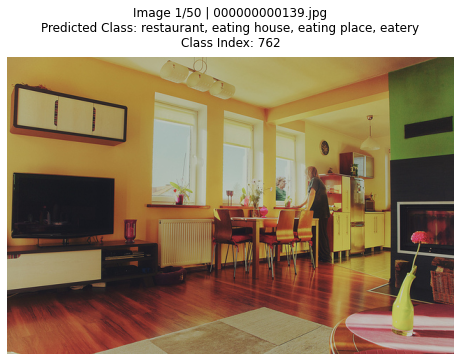

📌 正在处理第2/50张：000000000285.jpg


<Figure size 432x288 with 0 Axes>

📌 正在处理第3/50张：000000000632.jpg


<Figure size 432x288 with 0 Axes>

📌 正在处理第4/50张：000000000724.jpg


...

📌 正在处理第16/50张：000000001503.jpg


<Figure size 432x288 with 0 Axes>

📌 正在处理第17/50张：000000001532.jpg


<Figure size 432x288 with 0 Axes>


🔌 程序被手动中断（Ctrl+C）


In [1]:
#循环测试（只显示一张图片）
from transformers import MobileViTFeatureExtractor, MobileViTForImageClassification
from PIL import Image
import torch
import os
import matplotlib.pyplot as plt
import time  # 用于控制轮询显示的停留时间

# ---------------------- 1. 配置参数（需根据你的环境修改） ----------------------
# val2017 文件夹路径（存放待推理的图片，支持相对/绝对路径）
local_img_dir = "./val2017/val2017/"  # 示例：当前目录下的 val2017 文件夹
max_show_num = 50  # 最多显示50张图片
display_delay = 1  # 每张图片的显示停留时间（单位：秒），可根据需求调整
model_dir = "./"  # 本地模型文件夹路径（与原代码一致）

# 配置 matplotlib（解决中文乱码+开启交互模式，实现同一窗口更新）
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]  # 适配英文标签（若模型标签是中文，可加中文字体）
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示异常
plt.ion()  # 开启交互模式，允许同一窗口动态更新图像
fig, ax = plt.subplots(1, 1, figsize=(8, 6))  # 创建固定窗口和子图（仅1个窗口，1个子图）
# fig.suptitle("MobileViT Image Classification (Val2017)", fontsize=14, fontweight="bold")  # 窗口总标题


# ---------------------- 2. 工具函数：图片加载与文件夹遍历 ----------------------
def load_local_jpg(image_path):
    """加载本地JPG图片，包含路径/格式/读取校验"""
    # 校验路径是否存在
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"❌ 图片路径不存在：{image_path}")
    
    # 校验文件格式（仅支持JPG/JPEG）
    valid_ext = [".jpg", ".jpeg"]
    file_ext = os.path.splitext(image_path)[-1].lower()
    if file_ext not in valid_ext:
        raise ValueError(f"❌ 非JPG格式文件：{image_path}（后缀：{file_ext}）")
    
    # 加载图片并转为RGB（避免灰度图/透明通道问题）
    try:
        img = Image.open(image_path).convert("RGB")
        return img
    except Exception as e:
        raise RuntimeError(f"❌ 加载图片失败：{image_path} → {str(e)}")


def get_val2017_img_list(img_dir, max_num):
    """获取val2017文件夹下的图片列表（前max_num张，按文件名排序）"""
    # 校验文件夹是否存在
    if not os.path.isdir(img_dir):
        raise NotADirectoryError(f"❌ 文件夹不存在：{img_dir}")
    
    # 遍历文件夹，筛选JPG图片
    img_list = []
    for filename in os.listdir(img_dir):
        file_path = os.path.join(img_dir, filename)
        # 仅保留文件（排除子文件夹）+ JPG格式
        if os.path.isfile(file_path) and os.path.splitext(filename)[-1].lower() in [".jpg", ".jpeg"]:
            img_list.append(file_path)
    
    # 按文件名排序（保证每次读取顺序一致）
    img_list.sort()
    
    # 处理图片数量不足的情况
    actual_num = min(max_num, len(img_list))
    if actual_num < max_num:
        print(f"⚠️  警告：val2017文件夹仅含{len(img_list)}张图片，将显示全部{actual_num}张")
    
    return img_list[:actual_num]  # 返回前actual_num张图片路径


# ---------------------- 3. 初始化模型与特征提取器 ----------------------
try:
    # 加载本地模型（local_files_only=True 仅从本地读取，不联网）
    feature_extractor = MobileViTFeatureExtractor.from_pretrained(model_dir, local_files_only=True)
    model = MobileViTForImageClassification.from_pretrained(model_dir, local_files_only=True)
    model.eval()  # 切换为推理模式（禁用Dropout等训练层）
    print(f"✅ 成功加载本地模型：{model_dir}")
except Exception as e:
    raise RuntimeError(f"❌ 模型加载失败 → {str(e)}") from e


# ---------------------- 4. 核心逻辑：批量读取图片+推理+轮询显示 ----------------------
try:
    # 步骤1：获取val2017文件夹的图片列表
    img_path_list = get_val2017_img_list(local_img_dir, max_show_num)
    print(f"✅ 已获取{len(img_path_list)}张图片，开始推理与显示...\n")

    # 步骤2：循环处理每张图片（推理+显示）
    with torch.no_grad():  # 禁用梯度计算，加速推理+节省内存
        for idx, img_path in enumerate(img_path_list, 1):
            # ① 加载图片
            try:
                img = load_local_jpg(img_path)
                img_name = os.path.basename(img_path)  # 获取图片文件名（如000000039769.jpg）
                print(f"📌 正在处理第{idx}/{len(img_path_list)}张：{img_name}")
            except Exception as e:
                print(f"⚠️  跳过异常图片：{img_path} → {str(e)}")
                continue

            # ② 图片预处理（适配模型输入）
            inputs = feature_extractor(images=img, return_tensors="pt")

            # ③ 模型推理
            outputs = model(**inputs)
            logits = outputs.logits
            predicted_class_idx = logits.argmax(-1).item()  # 获取概率最大的类别索引
            predicted_class = model.config.id2label[predicted_class_idx]  # 转换为类别名称

            # ④ 在同一窗口更新显示（核心：用ax.clear()清除旧内容，再绘制新内容）
            ax.clear()  # 清除上一张图片的显示
            # 显示图片（PIL.Image → matplotlib可识别的格式）
            ax.imshow(img)
            # 设置当前图片的标题（包含序号、文件名、识别结果）
            ax.set_title(
                f"Image {idx}/{len(img_path_list)} | {img_name}\n"
                f"Predicted Class: {predicted_class}\n"
                f"Class Index: {predicted_class_idx}",
                fontsize=12, pad=10
            )
            ax.axis("off")  # 隐藏坐标轴，仅显示图片和标题

            # 刷新窗口并停留指定时间
            plt.draw()  # 强制刷新图像
            plt.pause(display_delay)  # 停留display_delay秒，让用户看清内容

    # 所有图片显示完成后，保持窗口直到用户手动关闭
    print("\n🎉 所有图片推理与显示完成！点击窗口关闭按钮退出程序...")
    plt.ioff()  # 关闭交互模式
    plt.show()  # 保持窗口显示（直到用户关闭）

except KeyboardInterrupt:
    print("\n🔌 程序被手动中断（Ctrl+C）")
except Exception as e:
    print(f"\n❌ 程序执行失败 → {str(e)}")
finally:
    # 确保程序退出时关闭matplotlib窗口
    plt.ioff()
    plt.close("all")

In [7]:
from transformers import MobileViTFeatureExtractor, MobileViTForImageClassification
from PIL import Image
import torch
import os
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display  # Jupyter显示工具

# ---------------------- 1. 配置参数 ----------------------
local_img_dir = "./val2017/val2017/"  # 图片文件夹路径
max_show_num = 50  # 最多显示50张图片
display_delay = 2  # 自动切换间隔（2秒）
model_dir = "./"  # 本地模型文件夹路径

# 配置matplotlib
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]
plt.rcParams["axes.unicode_minus"] = False
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.close()  # 初始关闭窗口，避免冗余输出


# ---------------------- 2. 工具函数 ----------------------
def load_local_jpg(image_path):
    """加载本地JPG图片并校验"""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"❌ Image path does not exist: {image_path}")
    
    valid_ext = [".jpg", ".jpeg"]
    file_ext = os.path.splitext(image_path)[-1].lower()
    if file_ext not in valid_ext:
        raise ValueError(f"❌ Non-JPG format file: {image_path} (extension: {file_ext})")
    
    try:
        img = Image.open(image_path).convert("RGB")
        return img
    except Exception as e:
        raise RuntimeError(f"❌ Failed to load image: {image_path} → {str(e)}")


def get_val2017_img_list(img_dir, max_num):
    """获取图片列表（按文件名排序）"""
    if not os.path.isdir(img_dir):
        raise NotADirectoryError(f"❌ Folder does not exist: {img_dir}")
    
    img_list = []
    for filename in os.listdir(img_dir):
        file_path = os.path.join(img_dir, filename)
        if os.path.isfile(file_path) and os.path.splitext(filename)[-1].lower() in [".jpg", ".jpeg"]:
            img_list.append(file_path)
    
    img_list.sort()
    actual_num = min(max_num, len(img_list))
    
    if actual_num < max_num:
        print(f"⚠️ Warning: Folder contains only {len(img_list)} images, will display all {actual_num}")
    else:
        print(f"✅ Retrieved {actual_num} images, starting processing...")
    
    return img_list[:actual_num]


# ---------------------- 3. 初始化模型 ----------------------
try:
    feature_extractor = MobileViTFeatureExtractor.from_pretrained(model_dir, local_files_only=True)
    model = MobileViTForImageClassification.from_pretrained(model_dir, local_files_only=True)
    model.eval()  # 推理模式
    print(f"✅ Successfully loaded model from: {model_dir}")
except Exception as e:
    raise RuntimeError(f"❌ Failed to load model → {str(e)}") from e


# ---------------------- 4. 核心逻辑（含处理时间统计） ----------------------
try:
    img_path_list = get_val2017_img_list(local_img_dir, max_show_num)
    total_num = len(img_path_list)

    with torch.no_grad():  # 禁用梯度计算，加速推理
        for idx, img_path in enumerate(img_path_list, 1):
            # ① 加载图片
            try:
                img = load_local_jpg(img_path)
                img_name = os.path.basename(img_path)
                print(f"📌 Processing {idx}/{total_num}: {img_name}")
            except Exception as e:
                print(f"⚠️ Skipping problematic image: {img_path} → {str(e)}")
                continue

            # ② 记录处理开始时间（包含预处理+推理）
            start_time = time.time()

            # ③ 预处理+模型推理
            inputs = feature_extractor(images=img, return_tensors="pt")
            outputs = model(**inputs)
            logits = outputs.logits
            predicted_class_idx = logits.argmax(-1).item()
            predicted_class = model.config.id2label[predicted_class_idx]

            # ④ 计算处理耗时（秒，保留2位小数）
            elapsed_time = round(time.time() - start_time, 2)

            # ⑤ 更新显示（含处理时间）
            ax.clear()
            ax.imshow(img)
            # 标题中添加处理时间：Processing Time: X.XXs
            ax.set_title(
                f"Image {idx}/{total_num} | {img_name}\n"
                f"Predicted Class: {predicted_class}\n"
                f"Class Index: {predicted_class_idx} | Processing Time: {elapsed_time}s",
                fontsize=12, pad=10
            )
            ax.axis("off")

            # Jupyter中自动刷新显示
            clear_output(wait=True)
            display(fig)
            time.sleep(display_delay)  # 等待2秒后自动切换

    # 处理完成后显示最终信息
    clear_output(wait=True)
    print("\n🎉 All images processed!")
    ax.set_title(
        f"Processing Complete | Total: {total_num} images\n"
        f"Last Image: {img_name} | Last Processing Time: {elapsed_time}s",
        fontsize=12, pad=10
    )
    display(fig)

except KeyboardInterrupt:
    clear_output(wait=True)
    print("\n🔌 Program interrupted manually (Ctrl+C)")
except Exception as e:
    clear_output(wait=True)
    print(f"\n❌ Program execution failed → {str(e)}")
finally:
    plt.close('all')


🔌 Program interrupted manually (Ctrl+C)
